In [ ]:
import pandas as pd

# Đọc dữ liệu từ tệp CSV

def clean_data(file_path, output_path):
    df = pd.read_csv(file_path)
    
    # Kiểm tra số lượng giá trị bị thiếu ở mỗi cột
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    missing_data = missing_data[missing_data['Missing Values'] > 0]
    
    print("Số lượng giá trị bị thiếu ở mỗi cột:")
    print(missing_data.sort_values(by='Missing Values', ascending=False))
    
    # Xóa các cột không cần thiết trước
    columns_to_drop = ['Restaurant penalty (Rejection)', 'Review', 'Instructions']
    df = df.drop(columns=columns_to_drop, errors='ignore')
    print("Các cột đã bị xóa:", columns_to_drop)
    
    # Loại bỏ các dòng trùng lặp
    df = df.drop_duplicates()
    
    # Chuyển đổi cột 'Order Placed At' thành kiểu datetime
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], format='%I:%M %p, %B %d %Y', errors='coerce')
    
    # Chuyển đổi 'Distance' thành số (loại bỏ km, xử lý "<1km" thành 0.5)
    df['Distance'] = df['Distance'].str.replace('km', '', regex=True)
    df['Distance'] = df['Distance'].replace('<1', 0.5).astype(float)
    
    # ---- BẮT ĐẦU PHẦN THÊM MỚI TỪ FILE2 ----
    print("\nĐang thực hiện các bước tiền xử lý bổ sung (từ file phân tích)...")

    # Điền giá trị số thiếu bằng median (Ở các cột: Rating, KPT, Rider wait time) - Chuyển từ FILE2
    numeric_cols_to_fill = ['Rating', 'KPT duration (minutes)', 'Rider wait time (minutes)']
    for col in numeric_cols_to_fill:
        # Kiểm tra xem cột có tồn tại không trước khi điền NaN
        if col in df.columns and df[col].isnull().any():
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"- Đã điền giá trị thiếu trong cột '{col}' bằng median ({median_val:.2f}).")
        elif col not in df.columns:
            print(f"- Cảnh báo: Cột '{col}' không tồn tại để điền giá trị thiếu.")
        elif not df[col].isnull().any():
             print(f"- Thông tin: Cột '{col}' không có giá trị thiếu để điền.")


    # Điền giá trị thiếu (NaN) cho cột 'Discount construct' bằng 'No Discount' - Chuyển từ FILE2
    if 'Discount construct' in df.columns and df['Discount construct'].isnull().any():
         df['Discount construct'] = df['Discount construct'].fillna('No Discount')
         print("- Đã điền giá trị thiếu trong cột 'Discount construct' bằng 'No Discount'.")
    elif 'Discount construct' not in df.columns:
         print("- Cảnh báo: Cột 'Discount construct' không tồn tại để điền giá trị thiếu.")
    elif not df['Discount construct'].isnull().any():
         print("- Thông tin: Cột 'Discount construct' không có giá trị thiếu để điền.")

    # ---- KẾT THÚC PHẦN THÊM MỚI TỪ FILE2 ----
    
    # Điền giá trị "None" cho các ô trống trong các cột yêu cầu
    df['Cancellation / Rejection reason'] = df['Cancellation / Rejection reason'].fillna("None")
    df['Customer complaint tag'] = df['Customer complaint tag'].fillna("None")
    
    # Xác định các hàng bị loại bỏ
    threshold = 0.2 * df.shape[1]  # Hơn 20% số cột bị thiếu dữ liệu
    dropped_rows = df[df.isnull().sum(axis=1) > threshold].index.tolist()
    
    # Loại bỏ các hàng có hơn 20% giá trị bị thiếu
    df = df.dropna(thresh=threshold, axis=0)
    
    print("Các hàng bị loại bỏ:", len(dropped_rows))
    
    # Lưu kết quả vào một tệp CSV mới
    df.to_csv(output_path, index=False)
    print(f"Dữ liệu đã được làm sạch và lưu vào: {output_path}")
    
    return df

# Đường dẫn đến tệp dữ liệu đầu vào và đầu ra
file_path = "order_history_kaggle_data.csv"
output_path = "cleaned_order_history.csv"
cleaned_df = clean_data(file_path, output_path)


Số lượng giá trị bị thiếu ở mỗi cột:
                                        Missing Values  Percentage
Restaurant penalty (Rejection)                   21318   99.985929
Restaurant compensation (Cancellation)           21188   99.376202
Cancellation / Rejection reason                  21135   99.127621
Review                                           21025   98.611697
Customer complaint tag                           20852   97.800291
Instructions                                     20601   96.623048
Rating                                           18830   88.316683
Discount construct                                5498   25.786783
KPT duration (minutes)                             295    1.383612
Rider wait time (minutes)                          168    0.787956
Các cột đã bị xóa: ['Restaurant penalty (Rejection)', 'Review', 'Instructions']

Đang thực hiện các bước tiền xử lý bổ sung (từ file phân tích)...
- Đã điền giá trị thiếu trong cột 'Rating' bằng median (5.00).
- Đã điền giá tr

TIỀN XỬ LÝ

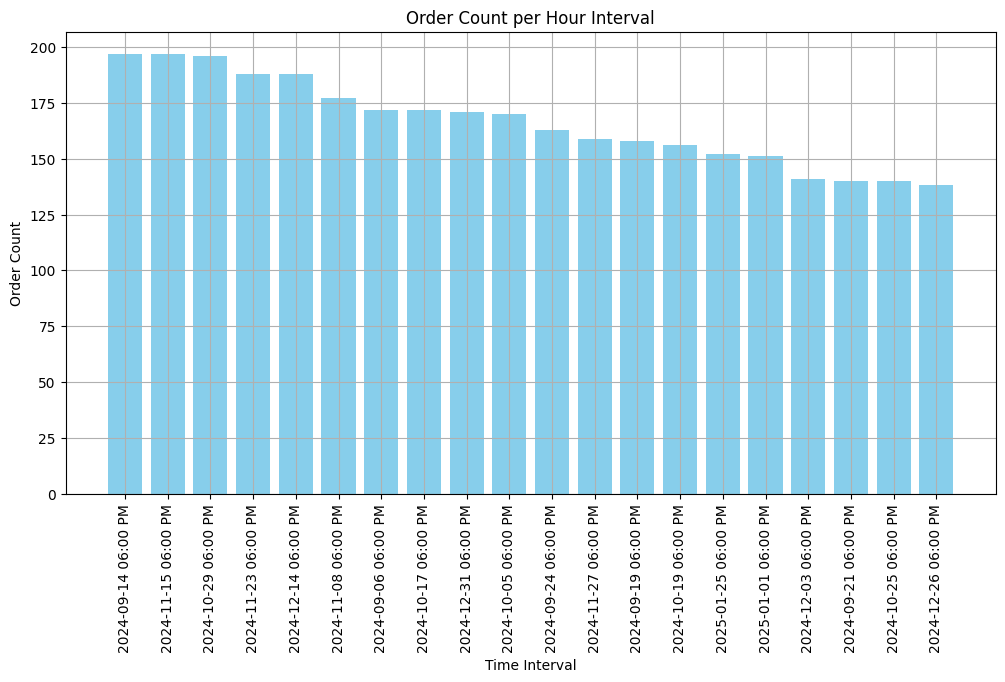

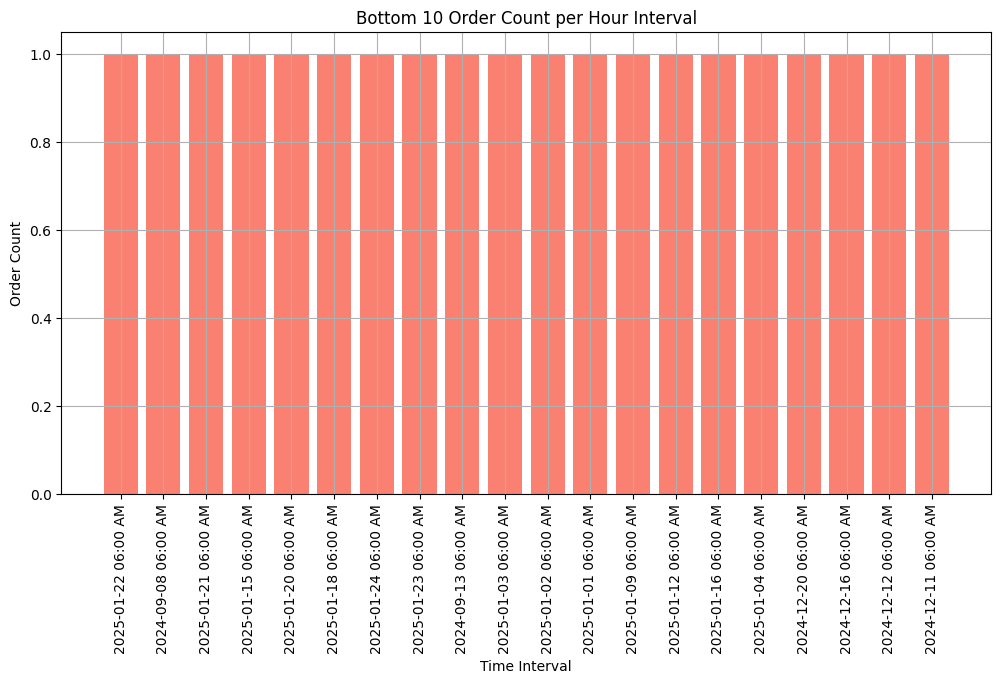

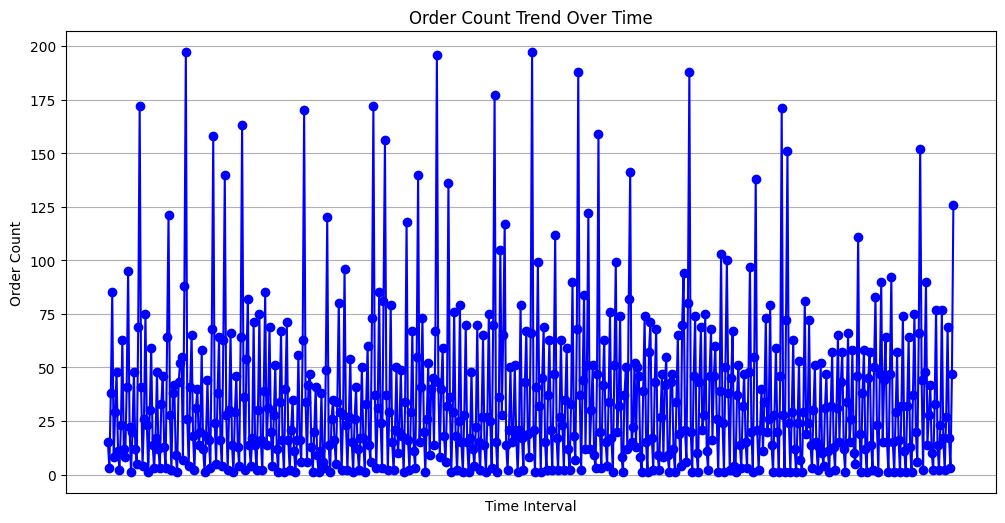

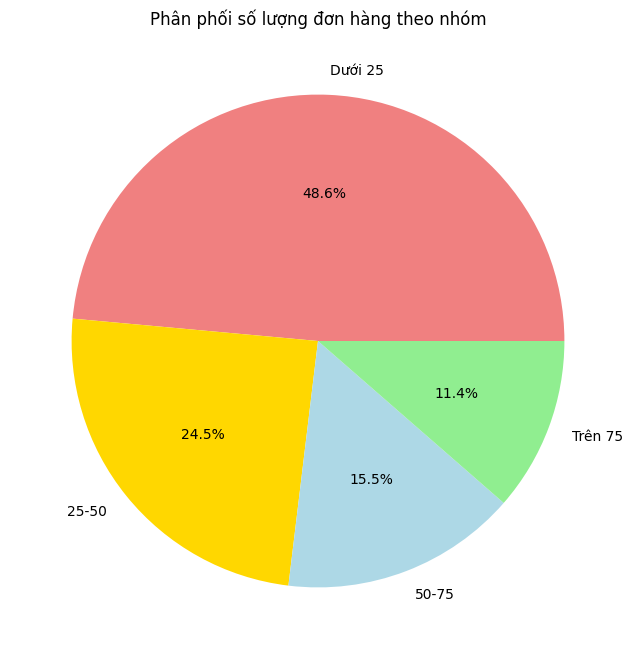


Bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):
   Order Hour Range  Order Count Order Category
2025-01-22 06:00 AM            1        Dưới 25
2024-09-08 06:00 AM            1        Dưới 25
2025-01-21 06:00 AM            1        Dưới 25
2025-01-15 06:00 AM            1        Dưới 25
2025-01-20 06:00 AM            1        Dưới 25
2025-01-18 06:00 AM            1        Dưới 25
2025-01-24 06:00 AM            1        Dưới 25
2025-01-23 06:00 AM            1        Dưới 25
2024-09-13 06:00 AM            1        Dưới 25
2025-01-03 06:00 AM            1        Dưới 25
2025-01-02 06:00 AM            1        Dưới 25
2025-01-01 06:00 AM            1        Dưới 25
2025-01-09 06:00 AM            1        Dưới 25
2025-01-12 06:00 AM            1        Dưới 25
2025-01-16 06:00 AM            1        Dưới 25
2025-01-04 06:00 AM            1        Dưới 25
2024-12-20 06:00 AM            1        Dưới 25
2024-12-16 06:00 AM            1        Dưới 25
2024-12-12 

,Order Hour Range,Order Count,Order Category
0,2024-09-01 12:00 AM,15,Dưới 25
1,2024-09-01 06:00 AM,3,Dưới 25
2,2024-09-01 12:00 PM,38,25-50
3,2024-09-01 06:00 PM,85,Trên 75
4,2024-09-02 12:00 AM,8,Dưới 25
...,...,...,...
95,2024-09-25 06:00 AM,2,Dưới 25
96,2024-09-25 12:00 PM,54,50-75
97,2024-09-25 06:00 PM,82,Trên 75
98,2024-09-26 12:00 AM,14,Dưới 25


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ tệp CSV và thêm cột đếm số lượng đơn hàng theo khung giờ
def process_data(file_path):
    df = pd.read_csv(file_path)
    
    # Chuyển đổi cột 'Order Placed At' thành kiểu datetime
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    
    # Tạo cột 'Order Hour Range' để nhóm theo từng khung giờ (cách nhau 6 tiếng)
    df['Order Hour Range'] = df['Order Placed At'].dt.floor('6h')#.dt.strftime('%Y-%m-%d %I:00 %p')
    
    # Đếm số lượng đơn hàng theo từng khung giờ
    order_counts = df.groupby('Order Hour Range').size().reset_index(name='Order Count')
    order_counts['Order Hour Range'] = pd.to_datetime(order_counts['Order Hour Range'], format='%Y-%m-%d %I:%M %p')
    order_counts = order_counts.sort_values(by='Order Hour Range')
    order_counts['Order Hour Range'] = order_counts['Order Hour Range'].dt.strftime('%Y-%m-%d %I:00 %p')
    
    # Vẽ biểu đồ số lượng đơn hàng theo thời gian
    plt.figure(figsize=(12, 6))
    top_20_orders = order_counts.sort_values(by='Order Count', ascending=False).head(20)
    plt.bar(top_20_orders['Order Hour Range'], top_20_orders['Order Count'], color='skyblue')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng ít nhất theo thời gian
    plt.figure(figsize=(12, 6))
    bottom_20_orders = order_counts.sort_values(by='Order Count', ascending=True).head(20)
    plt.bar(bottom_20_orders['Order Hour Range'], bottom_20_orders['Order Count'], color='salmon')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Bottom 10 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Vẽ biểu đồ đường thể hiện số đơn hàng theo từng khung giờ theo thời gian
    plt.figure(figsize=(12, 6))
    plt.plot(order_counts['Order Hour Range'], order_counts['Order Count'], marker='o', linestyle='-', color='b')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count Trend Over Time')
    plt.xticks([])
    plt.grid()
    plt.show()

    # Vẽ biểu đồ tròn phân phối số lượng đơn hàng
    plt.figure(figsize=(8, 8))
    bins = [0, 25, 50, 75, float('inf')]
    labels = ['Dưới 25', '25-50', '50-75', 'Trên 75']
    order_counts['Order Category'] = pd.cut(order_counts['Order Count'], bins=bins, labels=labels, right=False)
    category_counts = order_counts['Order Category'].value_counts()
    
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'gold', 'lightblue', 'lightgreen'])
    plt.title('Phân phối số lượng đơn hàng theo nhóm')
    plt.show()


 # Xuất bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (hiển thị 100 dòng đầu tiên)
    sorted_order_counts = order_counts.sort_values(by='Order Count', ascending=True).head(100)
    print("\nBảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):")
    print(sorted_order_counts.to_string(index=False))
    return order_counts

# Đường dẫn đến tệp dữ liệu đầu vào
file_path = "cleaned_order_history.csv"
processed_df = process_data(file_path)

processed_df.head(100)


Tạo 2 cột Order Hour Range (cách nhau 6 tiếng) và Order Count (số lượng đơn hàng) để rút ra insight trong quá khứ thông qua các biểu đồ:
- Khung giờ có nhiều đơn hàng nhất là từ 6:00 PM tới 12:00 AM hôm sau.
- Khung giờ có ít đơn hàng nhất là từ 6:00 AM tới 12:00 PM:
  + 6AM - 8AM: Các khu vực như Gurugram, Noida, và Ghaziabad thường chứng kiến ùn tắc nhẹ đến trung bình ở các điểm nút.
  + 8AM - 10AM: Đây là giờ cao điểm chính, Khu vực trung tâm Delhi có thể bị tắc nghẽn do lượng xe lớn, Các khu công nghiệp ở Noida và Faridabad cũng làm tăng áp lực giao thông trên các tuyến đường.
  + 10AM - 12PM: Giao thông bắt đầu giảm dần sau giờ cao điểm, nhưng vẫn có thể đông ở những khu vực thương mại và văn phòng như Nehru Place, Saket, và Cyber City (Gurugram).


Một số điểm nóng giao thông thường gặp:
- Delhi-Gurugram Border (NH-48): Thường xuyên ùn tắc vào buổi sáng do lượng xe từ Gurugram vào Delhi.
- DND Flyway: Kết nối Noida với Delhi, dễ bị chậm trễ nếu có kiểm tra xe hoặc lưu lượng cao.
- Ghaziabad (NH-24/NH-9): Giao thông đông đúc do kết nối với phía đông Delhi.
- Ring Road: Các đoạn gần ISBT Kashmiri Gate, Sarai Kale Khan thường xuyên tắc nghẽn.
